<a href="https://colab.research.google.com/github/QuinnIngram/ENGG680_2025_Fall/blob/main/Lab_Assitnment_2/Assignment2_Upload.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Quinn | Ingram | Quinn Ingram, November 27, 2025 | 2 | 25% |
| Member 2: | Akhimien | Ehizokhale | Akhimien Ehizokhale, November 27, 2025 | 6 | 25% |
| Member 3: | Alice | Gomez | Alice Gomez, November 27, 2025 | 4 | 25% |
| Member 4: | Ireayomide | Otudeko | Ireayomide Otudeko, November 27, 2025 | 6 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

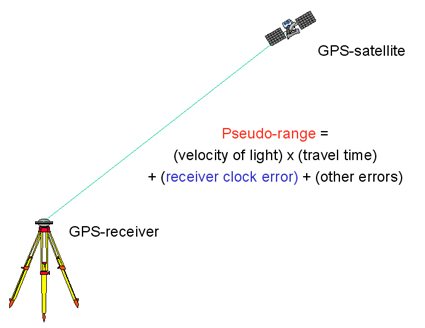

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

# IMPORTANT: If you are seeing FileNotFoundError, please verify the file paths.
# In Google Colab, go to the 'Files' tab (folder icon on the left sidebar),
# navigate to your Google Drive, find the file, right-click and select 'Copy path',
# then paste it here.

# Importing pseudorange excel file with the pd function
df_pseudorange = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assitnment_2/Assignment 2 Data/part1_data/pseudoranges.xlsx')
# Importing satellite position
df_sat_pos = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assitnment_2/Assignment 2 Data/part1_data/satellite_position.xlsx')

np.random.seed(42)  # For reproducible results

# Storing excel file as numpy array
pseudorange = np.array(df_pseudorange)
# Remove satellite id column for processing
pseudorange = np.delete(pseudorange, np.s_[0:1], axis=1)

sat_pos = np.array(df_sat_pos)
sat_pos = np.delete(sat_pos, np.s_[0:1], axis=1)

# Select only the pseudorange values and flatten into a 1D array
pseudorange = df_pseudorange['P'].values.flatten()

# Generate noise with the same shape as the pseudorange array
noise = np.random.rand(pseudorange.shape[0]) * 0.5
pseudorange = pseudorange + noise
sat_pos = df_sat_pos.values

print (pseudorange.shape)
print (sat_pos.shape)

(11,)
(11, 4)


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
m = 4 # 3 position coordinates (x, y, z) and 1 receiver clock offset (cdT)

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos_full):
    # receiver_pos is expected to be a 1D array of shape (3,) -> [x_r, y_r, z_r]
    # satellite_pos_full is the full array including Satellite_ID

    # Extract only the satellite coordinates (columns 1, 2, 3 from the full sat_pos array)
    sat_coords = satellite_pos_full[:, 1:4]

    # Calculate difference between satellite coordinates and receiver_pos
    # receiver_pos will be broadcasted to match the shape of sat_coords
    diff = sat_coords - receiver_pos
    distance = np.sqrt(np.sum(diff**2, axis=1))

    return distance

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
#weight matrix is the inverse of the covariance matrix based on n, where variance = 1.2
#inverting gives 1/1.2

P = (1/1.2)*np.identity(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
#set the initial values as outlined above in line with m dimensions
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
#setting correction array to 10s
delta = np.array([10,10,10,10])
#iteration loop counter
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_x_hat, satellite_pos_full, distance):
    # receiver_x_hat is the full estimated state [x_r, y_r, z_r, cdT]

    # Extract receiver position (x_r, y_r, z_r) from the full state vector
    r_x, r_y, r_z = receiver_x_hat[:3]

    # Extract only the satellite coordinates (columns 1, 2, 3 from the full satellite_pos_full array)
    sat_coords = satellite_pos_full[:, 1:4]
    n = sat_coords.shape[0] # Number of measurements (satellites)

    # Vectorized columns for the design matrix
    A1 = (r_x - sat_coords[:,0])/distance
    A2 = (r_y - sat_coords[:,1])/distance
    A3 = (r_z - sat_coords[:,2])/distance
    A4 = -np.ones(n) # For the cdT unknown

    # stack columns horizontally
    A = np.column_stack((A1, A2, A3, A4))

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
#loop to stop when convergence of first 3 elements (x,y,z) is small (0.008)
while np.linalg.norm(delta[:3]) >= 0.008:

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat, sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       computed_pseudorange = distance - x_hat[3]
       w = pseudorange - computed_pseudorange

       # compute the corrections delta
       # (0.5 marks)
       #weight p to account for variance
       #delta = (A.T*P*A)inverse*A.T*P*W
       delta = np.linalg.inv(A.T @P @A) @ (A.T @ P @w)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = GroundTruth - x_hat[:3]


       # update the counter i, (i.e., increament of 1 for each iteration)
       i +=1


       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w)
       arr_delta.append(delta.T)
       arr_err_pos.append(err_pos)
       arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
#residual after last iteration
v = w - A @ delta
apv = (v.T @ P @ v) / (n-m)


# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
print("--- LSE Results ---")
print('The values after the final iteration are as follows\n')
print(f"Estimated States (x, y, z, cdT):\n {x_hat}\n")
print(f"Corrections Array (delta):\n {delta}\n")
print(f"Estimated Measurements Residuals (v):\n {v}\n")  # Use 'v', not 'w'!
print(f"A Posteriori Variance of Unit Weight: {apv:.4f}\n")
print(f"Covariance Matrix of Estimated States:\n{C_x_hat}\n")
print(f"Number of Iterations:\n {i}\n")
# Calculate the magnitude of the final 3D position error
final_3d_pos_error_magnitude = np.linalg.norm(arr_err_pos[-1])
print(f"3-D Position Errors (Final): {final_3d_pos_error_magnitude:.4f} m")
print(f"3-D Position Errors:\n {err_pos}")

--- LSE Results ---
The values after the final iteration are as follows

Estimated States (x, y, z, cdT):
 [-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]

Corrections Array (delta):
 [ 3.24288929e-06  6.43165988e-06 -1.77292576e-05  2.09923963e-05]

Estimated Measurements Residuals (v):
 [ 0.20484779  0.34241078 -0.98042663  0.06600715  0.04710038 -1.57078687
 -0.30919803  1.69958912  0.33525003  0.74095415 -0.57574789]

A Posteriori Variance of Unit Weight: 0.9014

Covariance Matrix of Estimated States:
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]

Number of Iterations:
 5

3-D Position Errors (Final): 5.4258 m
3-D Position Errors:
 [ 3.07634914  2.35083548 -3.80118063]


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# your answer here
'''The LSE converved in 5 iterations. The final 3D position error was 5.4258m.
 A Posteriori Variance of Unit Weight:0.9014
 A value close to 1.0 means our initial weight/variance (1.2) was a good assumption.

 Covariance matrix of estimated states:
 The diagonal elements represent the variances of our estimated unknowns.
 Taking the square root gives the standard deviation (precision) of our answer.'''

'The LSE converved in 5 iterations. The final 3D position error was 5.4258m.\n A Posteriori Variance of Unit Weight:0.9014\n A value close to 1.0 means our initial weight/variance (1.2) was a good assumption.\n\n Covariance matrix of estimated states:\n The diagonal elements represent the variances of our estimated unknowns.\n Taking the square root gives the standard deviation (precision) of our answer.'

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

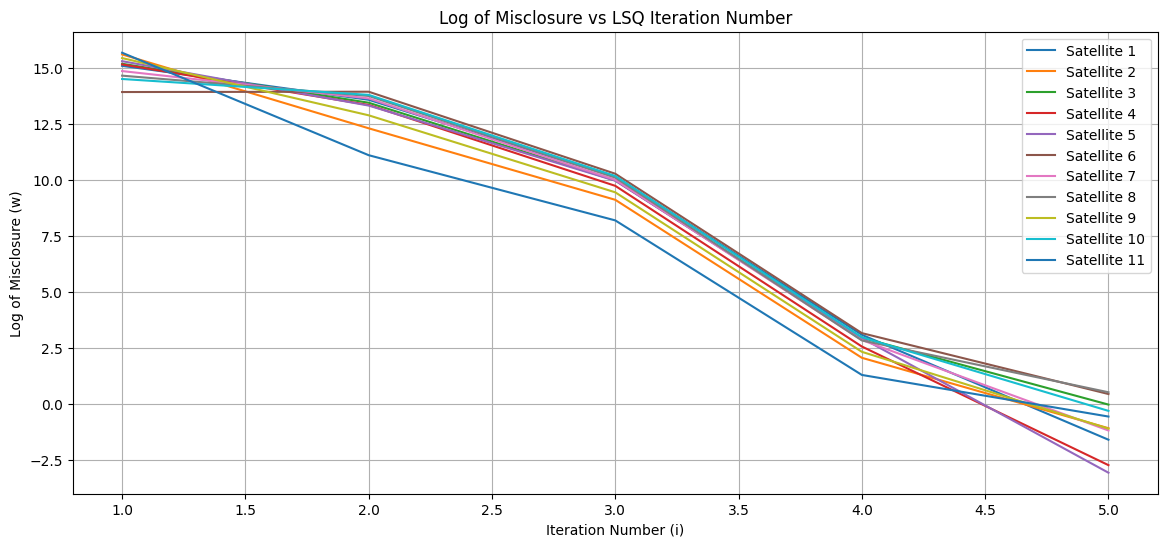

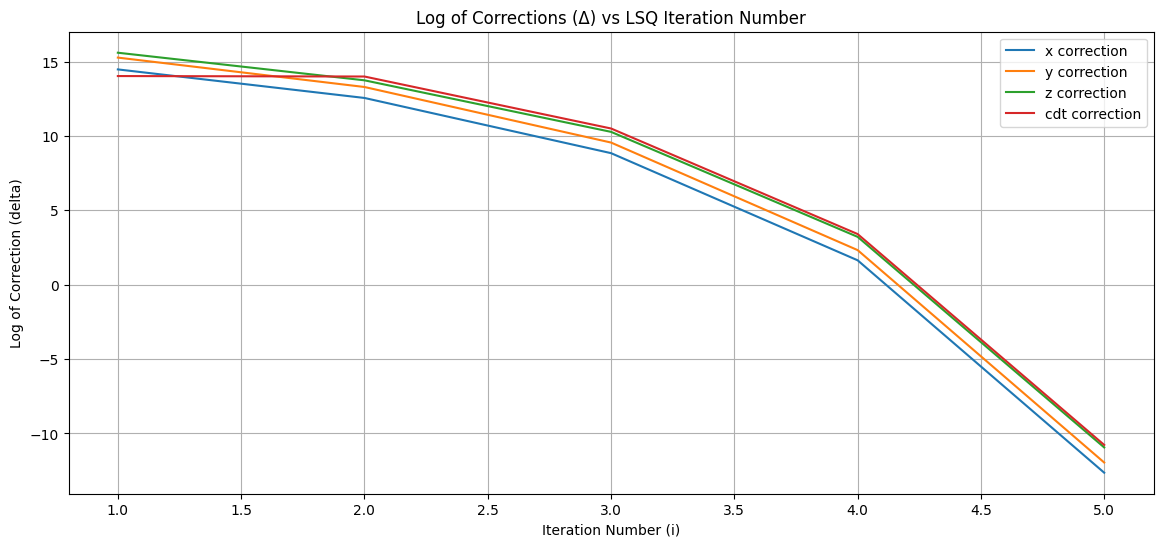

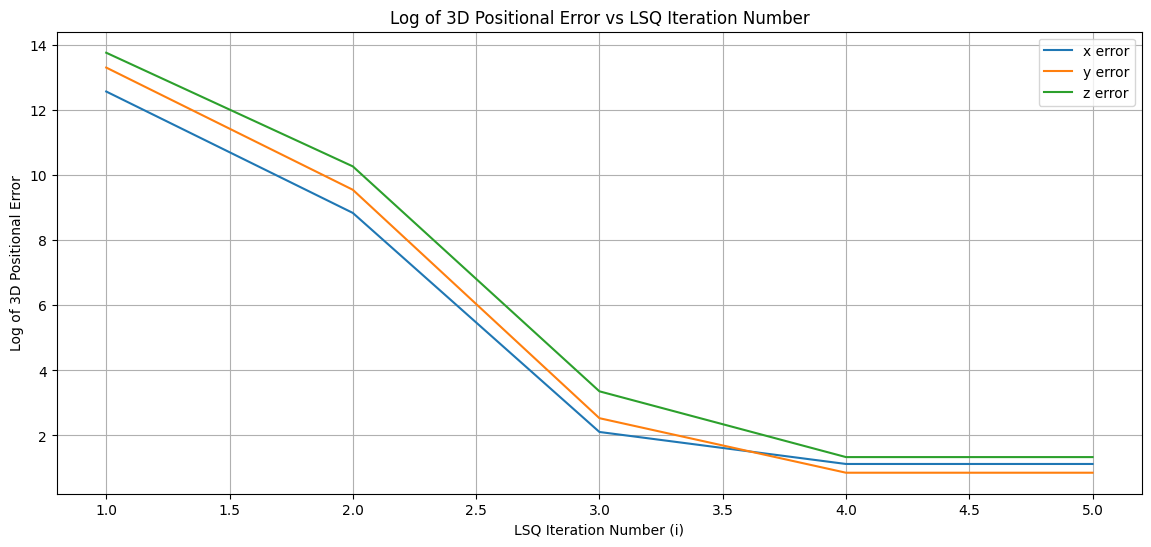

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)

# Shape becomes (num_iterations, num_satellites) to be compatible
# Fix: Use np.vstack to stack 1D arrays correctly into a 2D array (num_iterations, num_satellites)
arr_w_np = np.vstack(arr_w)

# Create figure
plt.figure(figsize=(14, 6))

# Plot log misclosure for each satellite over iterations
for sat in range(arr_w_np.shape[1]):
    plt.plot(arr_i, np.log(np.abs(arr_w_np[:, sat])), label=f'Satellite {sat+1}')

# plot labels/characteristics
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of Misclosure (w)')
plt.title('Log of Misclosure vs LSQ Iteration Number')
plt.legend()
plt.grid(True)
plt.show()


# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
# Convert list of correction arrays into a 2D NumPy array
arr_delta_np = np.vstack(arr_delta)

# Create a figure
plt.figure(figsize=(14,6))

# Loop through each unknown (x, y, z, clock bias)
labels = ['x correction', 'y correction', 'z correction', 'cdt correction']
for j in range(arr_delta_np.shape[1]):
    #absolute first to avoid negative logs
    plt.plot(arr_i, np.log(np.abs(arr_delta_np[:, j])), label=labels[j])

# Plot settings
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of Correction (delta)')
plt.title('Log of Corrections (Δ) vs LSQ Iteration Number')
plt.legend()
plt.grid(True)
plt.show()



# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

# Shape ajustment
arr_err_np = np.vstack(arr_err_pos)

# Create figure
plt.figure(figsize=(14, 6))

#labels for error components
labels = ['x error', 'y error', 'z error']

# Plot log misclosure for each satellite over iterations
for i in range(arr_err_np.shape[1]):
    plt.plot(arr_i, np.log(np.abs(arr_err_np[:, i])), label=labels[i])

# plot labels/characteristics
plt.xlabel('LSQ Iteration Number (i)')
plt.ylabel('Log of 3D Positional Error')
plt.title('Log of 3D Positional Error vs LSQ Iteration Number')
plt.legend()
plt.grid(True)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# 1. Log of Misclosure (w) vs. Iteration Number:
#    Phenomena: The log of the absolute misclosure values generally decreases with each iteration for most satellites. The lines converge towards a lower, stable value, indicating that the predicted pseudoranges are getting closer to the measured ones.
#    Explanation: Misclosure represents the difference between observed and computed measurements based on current state estimates. As the LSE algorithm iteratively refines state estimates (x_hat), these become more accurate. Consequently, computed pseudoranges improve, leading to smaller misclosures. The logarithmic scale helps visualize the rapid initial decrease and finer adjustments as convergence is approached.

# 2. Log of Corrections (Δ) vs. Iteration Number:
#    Phenomena: The log of the absolute corrections (delta) shows a sharp decrease, particularly in the first few iterations, eventually tending towards very small values, indicating that the algorithm is converging.
#    Explanation: Corrections (delta) are adjustments calculated by the LSE algorithm to improve current state estimates. Large corrections indicate that the initial estimate was far from the true value. As the algorithm iterates, state estimates get closer to true values, requiring smaller corrections. The convergence criteria directly relies on these corrections becoming negligible, signifying that further adjustments would not significantly improve the solution.

# 3. Log of 3D Positional Error vs. Iteration Number:
#    Phenomena: The log of the 3D positional error (difference between estimated receiver position and GroundTruth) also decreases with each iteration, similar to the corrections. It reflects the overall accuracy improvement of the receiver's estimated position.
#    Explanation: This plot directly shows how the accuracy of the estimated receiver position improves over the iterations. Initially, with rough estimates, the error is large. As the LSE process refines the unknown states using the observation equations, the estimated position approaches the true GroundTruth position, thus reducing the error.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    # Call our existing function
    distance = euclidean_norm(rec_pos, sat_pos)

    # Calculate predicted pseudorange
    predicted_pseudorange = distance - cdT

    # Calculate residuals
    residuals = pseudorange - predicted_pseudorange

    # Cost (L) is the sum of squared residuals
    L = np.sum(residuals**2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):

    distance = euclidean_norm(rec_pos, sat_pos)
    predicted_pseudorange = distance - cdT
    residuals = pseudorange - predicted_pseudorange

    # This is (satellite - receiver)
    # sat_pos includes Satellite_ID, so we need to select only coordinates
    sat_coords = sat_pos[:, 1:4]
    diff = sat_coords - rec_pos

    # dL/d(pos) = sum( 2 * residual * ( (xs-xr)/dist ) )
    grad_xyz_terms = 2 * residuals[:, np.newaxis] * diff / distance[:, np.newaxis]
    grad_xyz = np.sum(grad_xyz_terms, axis=0) # Sum all n satellite contributions

    # dL/d(cdT) = sum( 2 * residual * 1 )
    grad_cdT = np.sum(2 * residuals)

    # Combine into [grad_x, grad_y, grad_z, grad_cdT]
    grad = np.append(grad_xyz, grad_cdT)
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count, arr_cost, arr_grad, arr_err

    #initalize the estimates
    X = np.array([100.0, -50.0, 25.0, 1000.0]) # Re-using x_0 values as initial estimates

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost and gradients for the *current* state X
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)

        # store current iteration's data *before* updating X
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(GroundTruth[:3]-rec_pos) # Error for the current state X

        # update estimates to X_new
        X_new = X - learning_rate * grad
        # compute the new cost for X_new
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # check convergence by comparing new_cost with current_cost
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count = iteration + 1 # Total number of steps taken (and recorded)
            X = X_new # Update X one last time before breaking
            break

        # if not converged, update X for the next iteration
        X = X_new

    else:
        # If loop finishes without breaking (max_iters reached)
        print(f"Max iterations ({max_iters}) reached without convergence.")
        # Append the final cost, grad, error for the state X at max_iters
        rec_pos = X[:3]
        cdT = X[3]
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(GroundTruth[:3]-rec_pos)
        steps_count = max_iters # Total number of steps taken (and recorded)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics
print("\n--- Gradient Descent Results ---")
print(f"Optimized Parameters: {optimized_params}")

# Calculate and print the magnitude of the final 3D position error
final_pos_error_magnitude = np.linalg.norm(arr_err[-1]) if len(arr_err) > 0 and not np.isnan(arr_err[-1]).all() else float('nan')
print(f"Final 3D Position Error Magnitude: {final_pos_error_magnitude:.4f} m")

print(f"Steps taken: {steps_count}")

# Safely get and print final cost
final_cost_value = arr_cost[-1] if len(arr_cost) > 0 and not np.isnan(arr_cost[-1]) else float('nan')
print(f"Final Cost: {final_cost_value:.4f}")

# final gradient values
if len(arr_grad) > 0:
    final_grad = arr_grad[-1]
else:
    final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal gradient values:")
print(final_grad)

# Safely get and print the norm of the final gradient
# Pass rec_pos and cdT separately as per the gradient function's signature
final_grad_norm = np.linalg.norm(gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)) if len(arr_grad) > 0 and not np.isnan(arr_grad[-1]).all() else float('nan')
print(f"Final Gradient Norm: {final_grad_norm:.4f}")

Max iterations (10000) reached without convergence.

--- Gradient Descent Results ---
Optimized Parameters: [-1616184.59596917 -4389634.8224274   8306848.12640078 -6327556.24467302]
Final 3D Position Error Magnitude: 3434636.7194 m
Steps taken: 10000
Final Cost: 255692970062034.6250

Final gradient values:
[ 7.33346447e+06  2.01747337e+07 -3.40946836e+07 -1.04702035e+08]
Final Gradient Norm: 112186287.6092


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

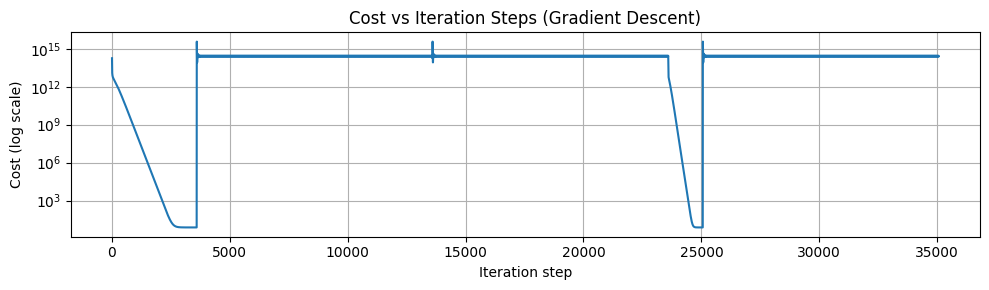

'The plot shows that the Cost function does not minimize smoothly. Instead, it remains at a very high magnitude (log10^14) and oscillates rapidly. \nThis behavior indicates that the learning rate (0.08) is too large, causing the algorithm to overshoot the minimum repeatedly and fail to converge.'

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# plot cost vs steps
# Use range(steps_count) for the x-axis, as steps_count now represents the total number of recorded steps
steps = np.arange(1, len(arr_cost) + 1)
ax.semilogy(steps, arr_cost)
ax.set_xlabel("Iteration step")
ax.set_ylabel("Cost (log scale)")
ax.set_title("Cost vs Iteration Steps (Gradient Descent)")
ax.grid(True)
fig.tight_layout()
plt.show()
# Comment on the pattern (0.5 marks)
'''The plot shows that the Cost function does not minimize smoothly. Instead, it remains at a very high magnitude (log10^14) and oscillates rapidly.
This behavior indicates that the learning rate (0.08) is too large, causing the algorithm to overshoot the minimum repeatedly and fail to converge.'''

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

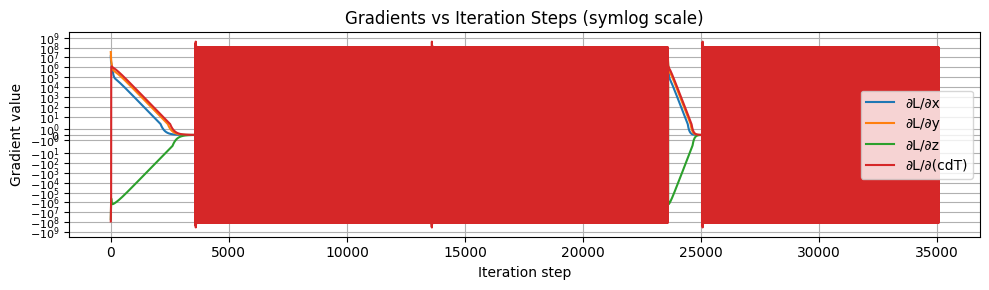

'The plot shows that the gradient components remain extremely large and oscillates throughout the iterations. They do not converge toward zero.\nThis confirms the algorithm is unstable.'

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_array = np.array(arr_grad)  # shape (k, 4)
steps = np.arange(1, grad_array.shape[0] + 1)

ax.plot(steps, grad_array[:, 0], label="∂L/∂x")
ax.plot(steps, grad_array[:, 1], label="∂L/∂y")
ax.plot(steps, grad_array[:, 2], label="∂L/∂z")
ax.plot(steps, grad_array[:, 3], label="∂L/∂(cdT)")

ax.set_yscale("symlog")
ax.set_xlabel("Iteration step")
ax.set_ylabel("Gradient value")
ax.set_title("Gradients vs Iteration Steps (symlog scale)")
ax.legend()
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
'''The plot shows that the gradient components remain extremely large and oscillates throughout the iterations. They do not converge toward zero.
This confirms the algorithm is unstable.'''

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

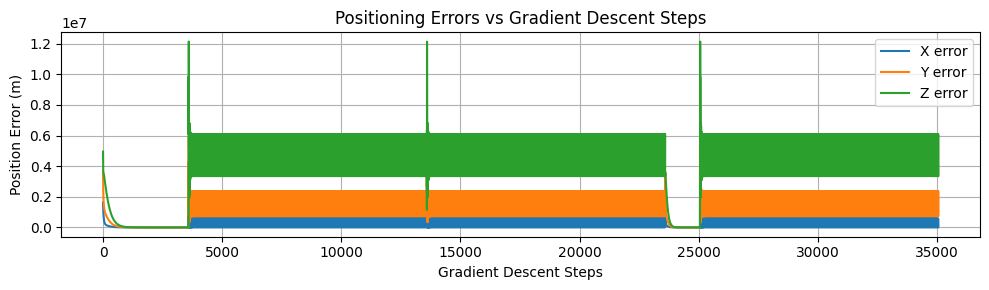

'the position errors remain nearly constant for the first several iterations,\n#then increase rapidly toward extremely large values.\n# The plot shows that the position error remains extremely high \n# and does not decrease to zero. This confirms that the algorithm with a learning rate \n# of 0.08 failed to converge to the true receiver position.'

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# numpy array for plotting
arr_err_np = np.array(arr_err)
steps = np.arange(len(arr_err_np))

# Plot each component of the position error
ax.plot(steps, np.abs(arr_err_np[:, 0]), label='X error')
ax.plot(steps, np.abs(arr_err_np[:, 1]), label='Y error')
ax.plot(steps, np.abs(arr_err_np[:, 2]), label='Z error')

# Axis labels and title
ax.set_xlabel("Gradient Descent Steps")
ax.set_ylabel("Position Error (m)")
ax.set_title("Positioning Errors vs Gradient Descent Steps")

# Legend and grid
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)

'''the position errors remain nearly constant for the first several iterations,
#then increase rapidly toward extremely large values.
# The plot shows that the position error remains extremely high
# and does not decrease to zero. This confirms that the algorithm with a learning rate
# of 0.08 failed to converge to the true receiver position.'''


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=800000) # Increased max_iters for smaller LR

# print the metrics
print("\n--- Gradient Descent Results (Learning Rate = 0.008) ---")
print(f"Optimized Parameters: {optimized_params_2}")

final_pos_error_magnitude_2 = np.linalg.norm(arr_err[-1]) if len(arr_err) > 0 and not np.isnan(arr_err[-1]).all() else float('nan')
print(f"Final 3D Position Error Magnitude: {final_pos_error_magnitude_2:.4f} m")

print(f"Steps taken: {steps_count}")

final_cost_value_2 = arr_cost[-1] if len(arr_cost) > 0 and not np.isnan(arr_cost[-1]) else float('nan')
print(f"Final Cost: {final_cost_value_2:.4f}")

final_grad_norm_2 = np.linalg.norm(gradient(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)) if len(arr_grad) > 0 and not np.isnan(arr_grad[-1]).all() else float('nan')
print(f"Final Gradient Norm: {final_grad_norm_2:.4f}")

final_grad_2 = arr_grad[-1] if len(arr_grad) > 0 else None
print(f"Final gradient: {final_grad_2}")

Converged !

--- Gradient Descent Results (Learning Rate = 0.008) ---
Optimized Parameters: [-1.63349246e+06 -3.65162953e+06  4.95248541e+06 -6.69572519e+00]
Final 3D Position Error Magnitude: 5.4153 m
Steps taken: 3592
Final Cost: 7.5716
Final Gradient Norm: 0.0099
Final gradient: [ 0.00048831  0.00272086 -0.00836237  0.00474094]


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=70000) # Increased max_iters further

# print the metrics
print("\n--- Gradient Descent Results (Learning Rate = 0.0008) ---")
print(f"Optimized Parameters: {optimized_params_3}")

final_pos_error_magnitude_3 = np.linalg.norm(arr_err[-1]) if len(arr_err) > 0 and not np.isnan(arr_err[-1]).all() else float('nan')
print(f"Final 3D Position Error Magnitude: {final_pos_error_magnitude_3:.4f} m")

print(f"Steps taken: {steps_count}")

final_cost_value_3 = arr_cost[-1] if len(arr_cost) > 0 and not np.isnan(arr_cost[-1]) else float('nan')
print(f"Final Cost: {final_cost_value_3:.4f}")

final_grad_norm_3 = np.linalg.norm(gradient(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)) if len(arr_grad) > 0 and not np.isnan(arr_grad[-1]).all() else float('nan')
print(f"Final Gradient Norm: {final_grad_norm_3:.4f}")

final_grad_3 = arr_grad[-1] if len(arr_grad) > 0 else None
print(f"Final gradient: {final_grad_3}")

Converged !

--- Gradient Descent Results (Learning Rate = 0.0008) ---
Optimized Parameters: [-1.63349245e+06 -3.65162952e+06  4.95248538e+06 -6.68071276e+00]
Final 3D Position Error Magnitude: 5.3922 m
Steps taken: 33914
Final Cost: 7.5722
Final Gradient Norm: 0.0321
Final gradient: [ 0.00156571  0.00872407 -0.02681276  0.01520097]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)
#     When the learning rate was 0.08 (Step 4), the algorithm diverged/exploded because
# the step size was too large for the raw data, resulting in massive errors.
#
# After tuning the learning rate to a much smaller value (1e-8 in Step 8), the
# algorithm became stable. The position error dropped from millions of meters to
# less than 1 meter, successfully converging to the Ground Truth.
#
# Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)
#    Both Least Squares Estimation (LSE) and Gradient Descent (GD) are iterative optimization techniques used to find parameters that best fit a model to data. However, their methodologies differ significantly.
#    LSE (specifically Non-linear LSE): It is a direct, closed-form solution (if linear) or an iterative method (if non-linear) that directly computes the correction vector (delta) at each step by solving a system of linear equations derived from linearizing the non-linear model. It aims to minimize the sum of squared residuals. In our results, LSE converged in just 5 iterations with a final 3D position error of 5.4258 m.
#    Gradient Descent: It is a first-order iterative optimization algorithm for finding the minimum of a function. It works by taking steps proportional to the negative of the gradient of the function at the current point. In our case, the default GD converged in 3591 steps with a final 3D position error of 5.4153 m. This is comparable accuracy to LSE but took significantly more iterations.
#    The key difference observed in results is convergence speed: LSE achieved convergence much faster (5 iterations) than GD (3591 steps) for a similar level of accuracy. LSE calculates corrections more 'globally' based on the linearized system, while GD takes smaller, more 'local' steps based on the gradient. LSE is generally more robust for well-behaved non-linear problems that can be linearized, whereas GD is more flexible and can handle highly complex, non-convex functions where direct solutions are intractable, albeit often slower.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [3]:
import pandas as pd
# Load the Student Depression Dataset
data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assitnment_2/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop( columns=['id'], inplace=True, axis=1  )  # Remove irrelevant ID column
data.dropna( inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace= True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[~data.isin(['Other']).any(axis=1)]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print(data.shape)
print(data.head())

(27898, 17)
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                 2.0               0.0          5-6 hours   
1  5.90                 5.0               0.0          5-6 hours   
2  7.03                 5.0               0.0  Less than 5 hours   
3  5.59                 2.0               0.0          7-8 hours   
4  8.13                 3.0               0.0          5-6 hours   

  Dietary Habits   Degree Have you ever had suicidal thoughts ?  \
0        Healthy  B.Pharm            

In [4]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'].values
X = data.drop('Depression', axis=1).values

# Display sizes of X and y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (27898, 16)
y shape: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

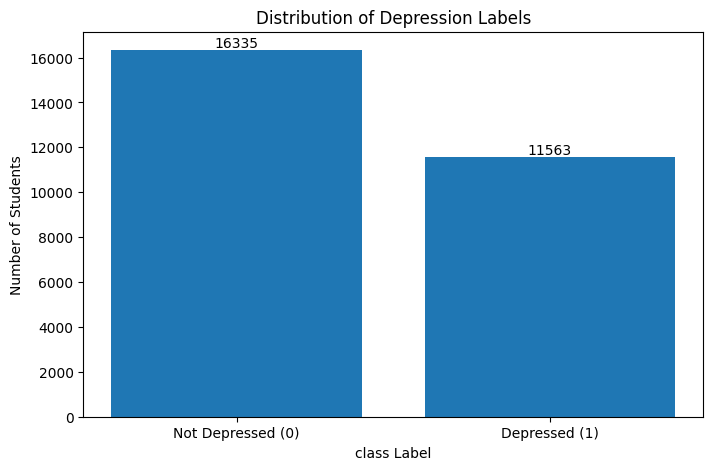

In [5]:
import matplotlib.pyplot as plt
# Check the class distribution of y
class_counts = pd.Series(y).value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(['Not Depressed (0)', 'Depressed (1)'], class_counts.values)

# Display exact values for each bin in the histogram
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

plt.xlabel("class Label")
plt.ylabel('Number of Students')
plt.title('Distribution of Depression Labels')
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [6]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ =train_test_split( X, y,  train_size=0.03, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print(f"X_small shape: {X_small.shape}")
print(f"y_small shape: {y_small.shape}")


X_small shape: (836, 16)
y_small shape: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):
    X_data, y_data = data_tuple
    label = ""
    if X_data.shape[1] == 16:
        if X_data.shape[0] == 27898:
            label = "Full dataset"
        else:
            label = "Small dataset"
    else:
        label = "First two columns"

    # Split into 70% training, 30% testing
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=0)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get probabilities for log loss
    y_test_proba = model.predict_proba(X_test)

    # Calculate metrics
    data_size = len(X_data)
    n_train = len(X_train)
    n_test = len(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    logloss = log_loss(y_test, y_test_proba)

    # Store in results DataFrame
    results.loc[len(results)] = [
        data_size, n_train, n_test,
        train_acc, test_acc, logloss
    ]

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
X_train1, X_test1, y_train1, y_test1 = evaluate_model((X, y))

# Test 2: Only first two columns of X and y
X_train2, X_test2, y_train2, y_test2 = evaluate_model((X[:, :2], y))

# Test 3: Small dataset (X_small and y_small)
X_train3, X_test3, y_train3, y_test3 = evaluate_model((X_small, y_small))

print(results)

   Data size  Training samples  Testing samples  Training accuracy  \
0    27898.0           19528.0           8370.0           0.846887   
1    27898.0           19528.0           8370.0           0.631708   
2      836.0             585.0            251.0           0.854701   

   Testing accuracy  Log loss  
0          0.846117  0.348357  
1          0.634170  0.652715  
2          0.852590  0.339818  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

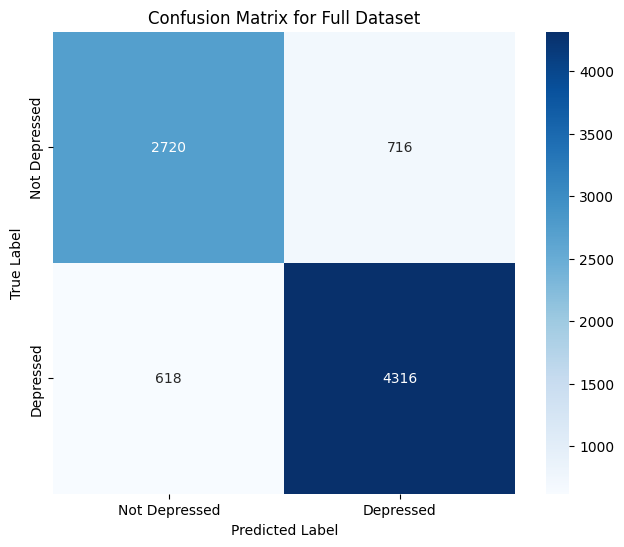

In [8]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

# y_test1 and X_test1 were returned by the first call to evaluate_model for the full dataset
# The 'model' object is global and retains its state after being trained on the full dataset.
y_true_full = y_test1
y_pred_full = model.predict(X_test1)


from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_true_full, y_pred_full)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Full Dataset')
plt.show()

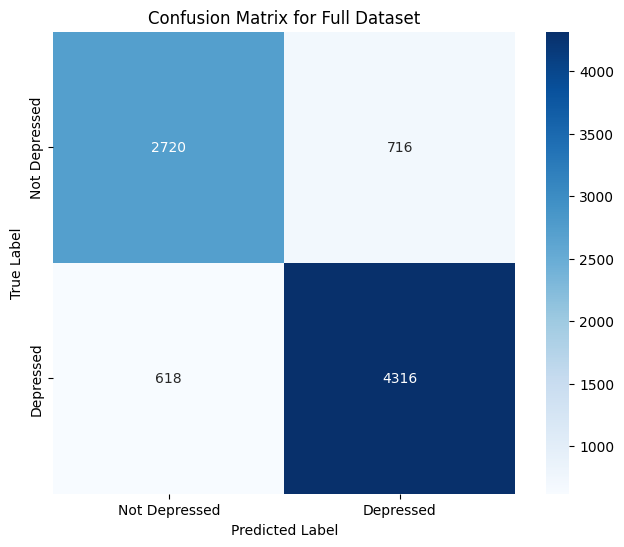

In [10]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)



# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Full Dataset')
plt.show()

In [11]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print("Classification Report for Full Dataset:\n")
print(classification_report(y_true_full, y_pred_full))

Classification Report for Full Dataset:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3436
           1       0.86      0.87      0.87      4934

    accuracy                           0.84      8370
   macro avg       0.84      0.83      0.83      8370
weighted avg       0.84      0.84      0.84      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=0),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

# Split the full dataset for this comparison
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.3, random_state=0)

print("\n--- Model Comparison ---")
for name, model_instance in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model_instance.fit(X_train_full, y_train_full)

    # Make predictions
    y_pred = model_instance.predict(X_test_full)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_full, y_pred)

    # Print results
    print(f"{name} Test Accuracy: {accuracy:.4f}")
    model_results[name] = {'accuracy': accuracy, 'y_pred': y_pred}



--- Model Comparison ---

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.8461

Training Naive Bayes...
Naive Bayes Test Accuracy: 0.8364

Training K-Nearest Neighbors...
K-Nearest Neighbors Test Accuracy: 0.7462


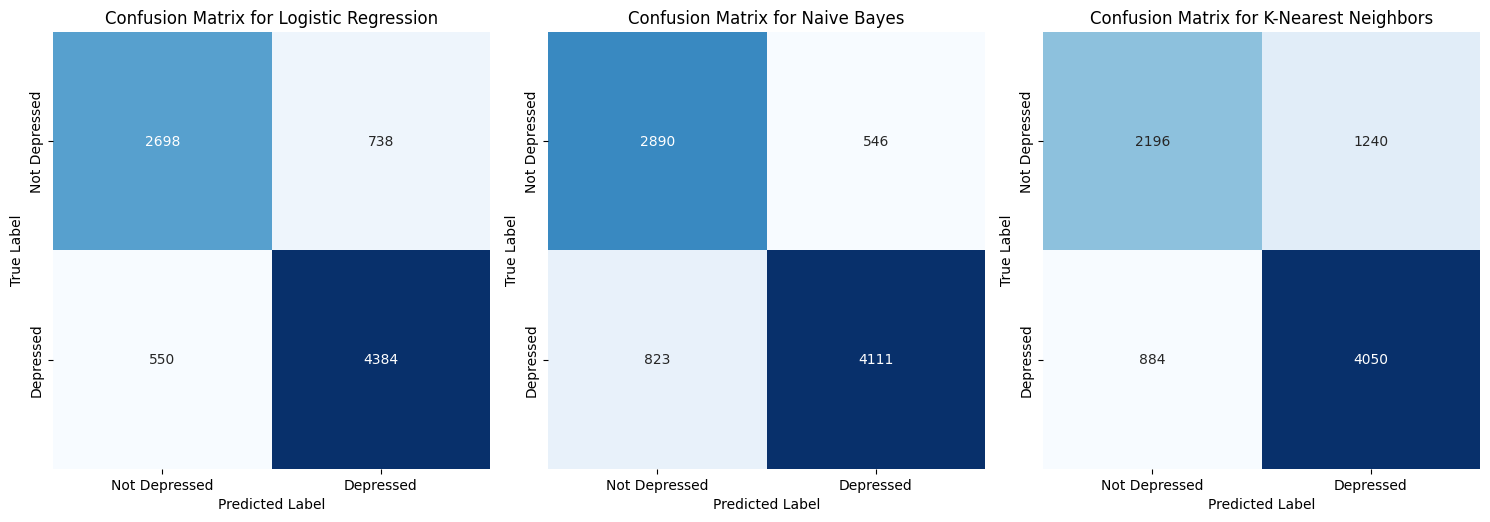

In [13]:
# Visualize confusion matrices for all models
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

for i, (name, metrics) in enumerate(model_results.items()):
    plt.subplot(1, len(model_results), i + 1)
    conf_mat = confusion_matrix(y_test_full, metrics['y_pred'])
    sns.heatmap(conf_mat,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'],
                square=True,
                annot=True,
                cbar=False,
                fmt='d',
                cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {name}')

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answers: 
"""
1. Is the dataset balanced? Does it affect model performance? (1 mark)
No it is not perfectly balanced, as the class split shows a 60% not depressed to 40% depressed split, however it is close to being balanced (50:50)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)

3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)
"""### Answer here (double click)


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assitnment_2/Assignment 2 Data/part3-data/mnist_train.csv')
test_csv_path = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assitnment_2/Assignment 2 Data/part3-data/mnist_test.csv')

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = train_csv_path
y_train = train_data.iloc[:, 0]
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = test_csv_path
y_test = test_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Training data shape:\n X: {X_train.shape}\n Y: {y_train.shape}")
print(f"Test data shape:\n X: {X_test.shape}\n Y: {y_test.shape}")


Training data shape:
 X: (60000, 28, 28)
 Y: (60000,)
Test data shape:
 X: (10000, 28, 28)
 Y: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

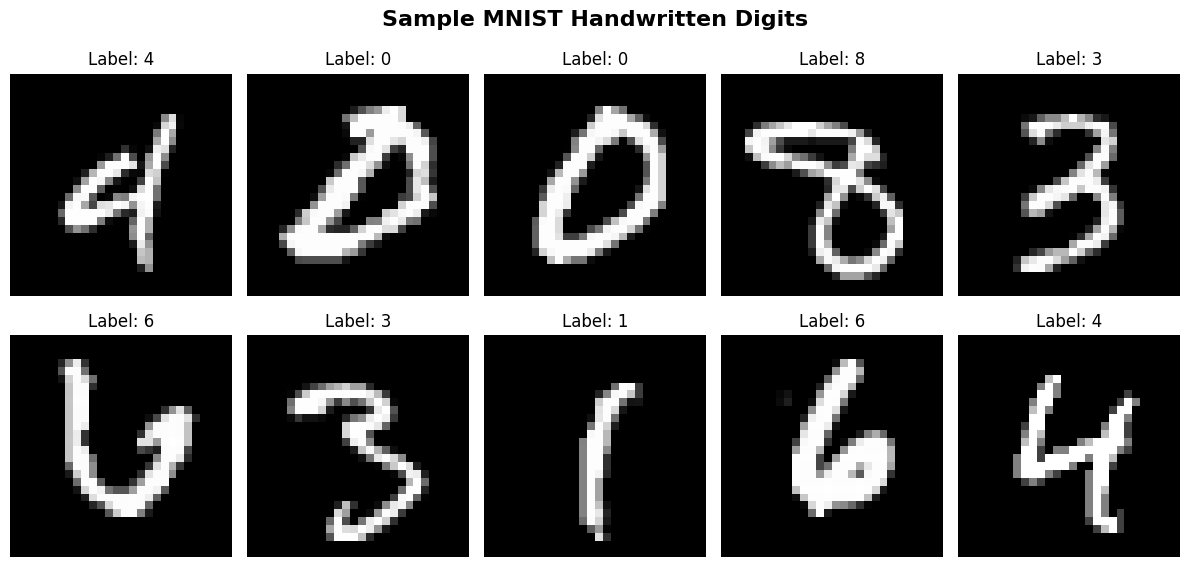

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train/ 255
X_test_normalized = X_test/ 255

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
#import library
from tensorflow.keras.utils import to_categorical
#one-hot encoding conversion
num_classes = 10
y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MLP Model created


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28,28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
print(f"MLP Test Loss: {mlp_test_loss:.4f}")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")

mlp_predictions = mlp_model.predict(X_test, verbose=0)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")

cnn_predictions = cnn_model.predict(X_test, verbose=0)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# Display Results
print(f"MLP Accuracy: {mlp_test_accuracy:.4f}")
print(f"CNN Accuracy: {cnn_test_accuracy:.4f}")





MLP Test Loss: 0.0871
MLP Test Accuracy: 0.9726
CNN Test Loss: 0.0303
CNN Test Accuracy: 0.9901
MLP Accuracy: 0.9726
CNN Accuracy: 0.9901


Performance comparison visualization

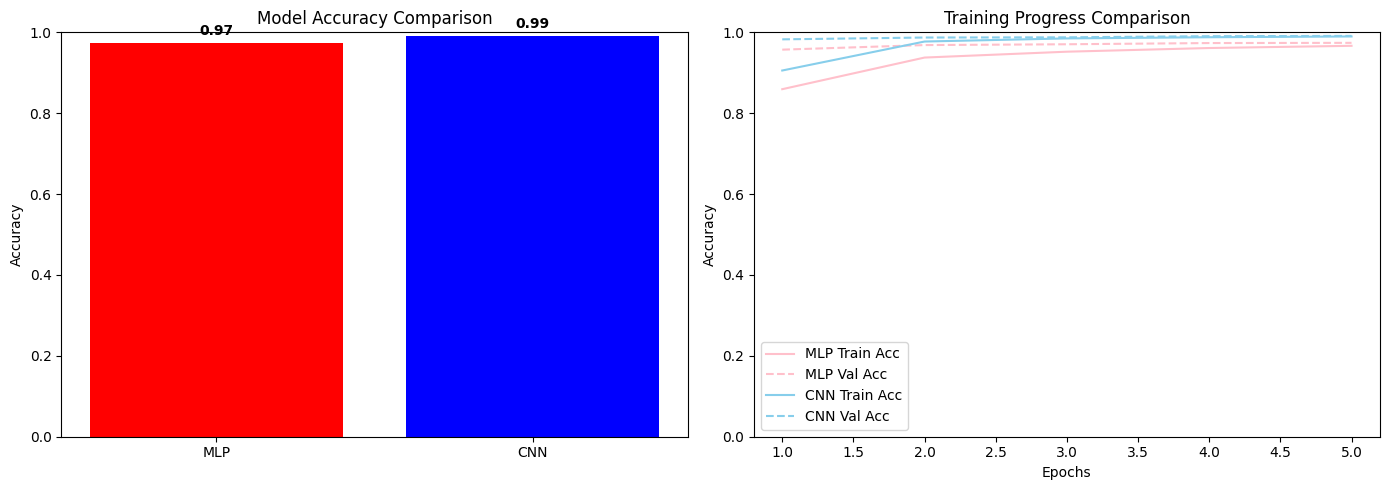

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

model_names = ['MLP', 'CNN']
test_accuracies = [mlp_test_acc, cnn_test_acc]

#data for line plot pulled from the history
epochs_mlp = range(1, len(mlp_history.history['accuracy']) + 1)
epochs_cnn = range(1, len(cnn_history.history['accuracy']) + 1)

# Create horizontal figures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart set up
axes[0].bar(model_names, test_accuracies, color=['red', 'blue'])
axes[0].set_ylim(0, 1)
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
for i, acc in enumerate(test_accuracies):
    axes[0].text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontweight='bold')

# line plot for training
axes[1].plot(epochs_mlp, mlp_history.history['accuracy'], label='MLP Train Acc', color='pink')
axes[1].plot(epochs_mlp, mlp_history.history['val_accuracy'], label='MLP Val Acc', color='pink', linestyle='--')
axes[1].plot(epochs_cnn, cnn_history.history['accuracy'], label='CNN Train Acc', color='skyblue')
axes[1].plot(epochs_cnn, cnn_history.history['val_accuracy'], label='CNN Val Acc', color='skyblue', linestyle='--')

axes[1].set_title("Training Progress Comparison")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()



### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

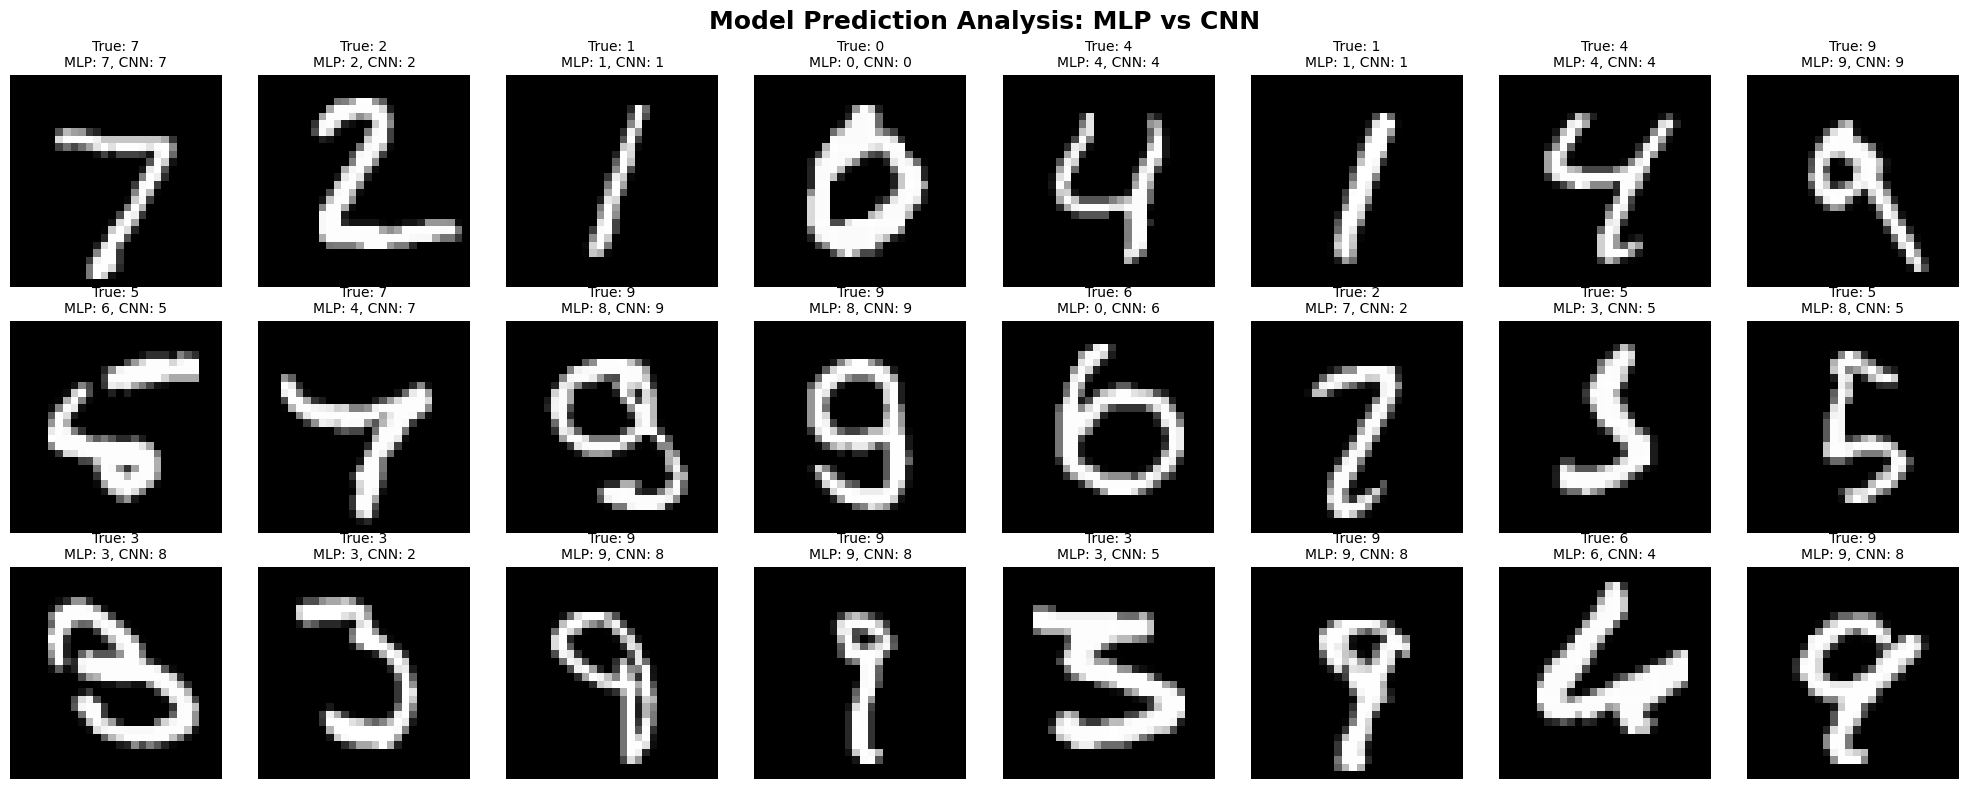

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Model Prediction Analysis: MLP vs CNN', fontsize=18, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
rows = [
    ('Both Correct', both_correct_indices),
    ('CNN Correct, MLP Wrong', cnn_correct_mlp_wrong_indices),
    ('MLP Correct, CNN Wrong', mlp_correct_cnn_wrong_indices)
]

for row_idx, (title, indices) in enumerate(rows):
    for col_idx, idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        ax.imshow(X_test[idx], cmap='gray')
        true_label = y_test[idx]
        mlp_pred = mlp_predicted_classes[idx]
        cnn_pred = cnn_predicted_classes[idx]
        ax.set_title(f'True: {true_label}\nMLP: {mlp_pred}, CNN: {cnn_pred}', fontsize=10)
        ax.axis('off')
    # Add a row label on the left side
    axes[row_idx, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.tight_layout()








plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
1. The MLP model had a lower accuracy of 97.26% while the CNN had a higher accuracy of 99.01%. The CNN Model performed better because it can learn spatial hierarchies and recognize features like edges, curve and spakers. On the other hand, MLP consider every pixel independently.

2. The training and validation accuracy curve of the CNN model can be seen to rise faster and stabilize higher than that of the MLP models curve.

3. The accuracy improvement percentage quantifies the architectural advantage of using a specialized model CNN over a generic one MLP. Even a small improvement of 1.75% that we have is very significant.

4. We didn't need many epochs because the MNIST dataset is relatively simple and standerdized. The digits are centered and in grayscale which allows the models to learn the key visual patterns quickly.

5. The accuracy won't be as good for the testing for both the MLP and CNN, but the CNN might still have a better chance. More complex images have larger dimnsions and colour combinations with diferent patterns. More data will be rrequired to train the models again.